### Simple Linear Regression

#### Steps 

1. Initialize the feature from independent and dependent features


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [65]:
df = pd.read_excel('SLR.xlsx')

In [66]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [67]:
X = df[['Weight']]
y = df['Height']

2. train test split

In [68]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [69]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

3. Standardization or Feature Selection

We always use Fit and transform in Independent feature and it has to be in 2D.. else it will give Error

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Model Selection

In [72]:
regressor = LinearRegression()

Fitting the train data

In [73]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
print("Coefficients or slope:", regressor.coef_) # in simple linear regression, there is only one coefficient or slope, 
# which represents the change in the dependent variable (Height) for a one-unit change in the independent variable (Weight).
print("Intercept:", regressor.intercept_)

Coefficients or slope: [16.92346722]
Intercept: 157.5


##### y_pred = intercept + slope(weights)

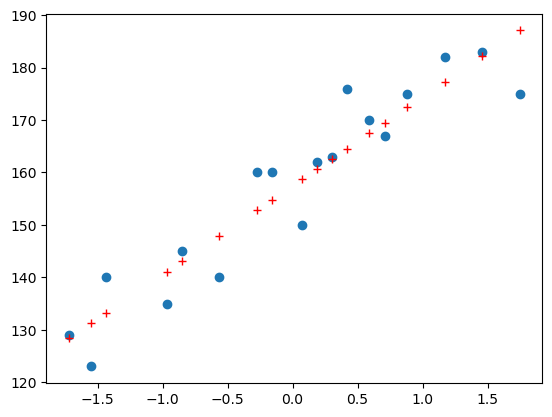

In [92]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train_scaled), 'r+')

Prediction

In [76]:
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

In [77]:
y_pred_test, y_test

(array([160.65446583, 160.65446583, 128.3483847 , 177.29699248,
        147.92782781]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

In [78]:
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

Mean Squared Error: 113.78445994739195
Root Mean Squared Error: 10.666979888768514
Mean Absolute Error: 9.962926547137068


In [79]:
score = r2_score(y_test, y_pred_test)

In [80]:
score

0.7688435317174712

In [81]:
# Adjusted R2 Score
adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print('Adjusted R2 Score: ', adjusted_r2)

Adjusted R2 Score:  0.691791375623295


## New data point

In [82]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
weight = [[80]]
scaled_weight =scaler.transform(weight)# Replace 80 with the weight value you want to predict the height for

c:\Users\iamsi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [86]:
scaled_weight

array([[0.30209]])

In [87]:
regressor.predict([scaled_weight[0]])

array([162.61241015])

In [88]:
residuals = y_test - y_pred_test
residuals

15    16.345534
9      9.345534
0     -8.348385
8      4.703008
17    11.072172
Name: Height, dtype: float64

C:\Users\iamsi\AppData\Local\Temp\ipykernel_11148\2928340742.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde = True)


<Axes: xlabel='Height', ylabel='Density'>

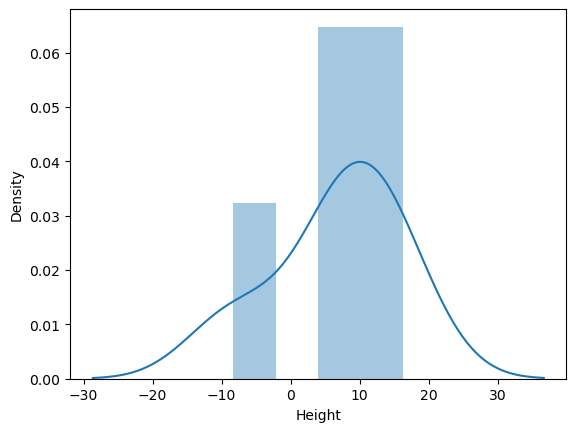

In [90]:

sns.distplot(residuals, kde = True)